In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr
import xarray as xr
import sys

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
# from taylor_setup import *
from setup_diagnostic import *

In [2]:
# %% 1. Settings: full-record high-pass variability, separate from the running maps
import numpy as np
import xarray as xr
from scipy import signal
from pathlib import Path
from datetime import datetime, timezone

hp_core_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412")
hp_raw_dir = Path("/scratch/leiff/MCA/amip_clean/data")
hp_regional_path = hp_core_dir / "stationarity/regional/march_n178_regional.npy"
hp_run_dir = hp_core_dir / "fullperiod_highpass/SEP_10yr_run01"
hp_experiments = ["historical", "historical_matched", "amip_hist"]
hp_region = "SEP"
hp_first_month, hp_last_month = "1870-01", "2014-12"
hp_confirmed_member_ids = None  # Optional {physical_experiment: {model: IDs in ARCHIVED order}}.
hp_resume = False              # True resumes this SAME unchanged run; never run two writers here.
hp_save_figures = True

# Frequency is cycles/month. By default the FINAL zero-phase amplitude response
# is 1/sqrt(2) at a 10-year period; the single-pass design is adjusted below.
# Choose 'single_pass' instead to get final amplitude 1/2 at the nominal cutoff.
hp_cutoff_years, hp_order = 10., 4
hp_cutoff_convention = "final_half_power"
hp_padtype = "odd"
hp_padlen_months = None        # None uses three cutoff periods of reflected padding.
hp_tail_tolerance = .01        # <=1% of absolute impulse mass may remain beyond the trim.
hp_trim_months = None          # None uses the pulse test, rounded UP to whole years.
hp_min_retained_months = 120
hp_padding_check = True        # Also test even padding; save per-member sensitivity summaries.
hp_extra_trim_months = 24      # Recalculate D after two additional years trimmed at each end.
hp_ddof = 1

# No monthly detrending, ensemble-mean subtraction, or LFCA in this branch.
# Completed members are checkpointed; restarting rebuilds means from ALL members.
# Later load/plot only: run cells 1, 9, 10, 11. Filter QC can also be plotted via
# cells 3 and 6 after cell 9; the saved filter diagnostics need no raw data.




In [3]:
# %% 2. Your climatology-only function (with finite-value rather than NaN-only masking)
def remove_monthly_climatology_fast(arr, start_month):
    """Remove calendar-month means, not month-specific trends; time is axis 0.

    Months must be consecutive. Missing observations retain their calendar
    positions. This function tolerates NaNs; the FILTER below requires complete
    input on the fixed weighted domain and does not interpolate missing data.
    """
    arr = np.asarray(arr, dtype=float)
    if arr.ndim == 0:
        raise ValueError("arr must have a time dimension")
    if not isinstance(start_month, (int, np.integer)) or not 1 <= start_month <= 12:
        raise ValueError("start_month must be an integer from 1 to 12")
    n_time, pad_shape = arr.shape[0], arr.shape[1:]
    n_before = start_month - 1
    n_after = (-(n_before + n_time)) % 12
    before, after = np.full((n_before,) + pad_shape, np.nan), np.full((n_after,) + pad_shape, np.nan)
    padded = np.concatenate((before, arr, after), axis=0)
    by_month = padded.reshape((padded.shape[0] // 12, 12) + pad_shape)
    valid = np.isfinite(by_month)
    n_valid = valid.sum(axis=0)
    monthly_sum = np.where(valid, by_month, 0.).sum(axis=0)
    monthly_climatology = np.divide(monthly_sum, n_valid, out=np.full_like(monthly_sum, np.nan), where=n_valid > 0)
    anomalies = by_month - monthly_climatology[None]
    anomalies[~valid] = np.nan
    return anomalies.reshape(padded.shape)[n_before:n_before + n_time]




In [4]:
# %% 3. Filter design and pulse/edge tests; no climate data are changed here
def hp_design_filter(n_months, cutoff_years, order, convention, tail_tolerance,
                     padtype="odd", padlen=None, trim_months=None, min_retained=120):
    """Return the actual coefficients, response, trimming rule and synthetic QC.

    The tail criterion is sum(|h| outside +/-L)/sum(|h|), not a p-value or a
    guarantee about every real boundary. Synthetic endpoint and real-data
    padding/extra-trim checks supplement it. All models get the SAME trim.
    """
    if not np.isfinite(cutoff_years) or cutoff_years <= 1/6 or not isinstance(order, (int, np.integer)) or order < 1:
        raise ValueError("Need a positive integer order and cutoff period above the two-month Nyquist period.")
    if not 0 < tail_tolerance < 1 or convention not in ["final_half_power", "single_pass"]:
        raise ValueError("Check cutoff convention and 0 < tail_tolerance < 1.")
    if padtype not in ["odd", "even", "constant"]:
        raise ValueError("Choose odd, even or constant padding.")
    period_months, fs = 12*float(cutoff_years), 1.
    requested_frequency = 1/period_months
    design_frequency = requested_frequency
    if convention == "final_half_power":
        # Forward-backward amplitude = 1/[1+(Omega_c/Omega)^(2*order)].
        # Solve for gain=1/sqrt(2) at the requested frequency, with the digital
        # frequency warping handled by tan/atan, not a low-frequency approximation.
        factor = (np.sqrt(2.) - 1.)**(1/(2*order))
        design_frequency = fs/np.pi*np.arctan(np.tan(np.pi*requested_frequency/fs)*factor)
    sos = signal.butter(order, design_frequency, btype="highpass", fs=fs, output="sos")
    padlen = int(np.ceil(3*period_months)) if padlen is None else padlen
    if not isinstance(padlen, (int, np.integer)) or not 0 <= padlen < n_months - 1:
        raise ValueError("Padding must be an integer shorter than the input record minus one month.")

    # Use a long, centered unit impulse. Its tails must settle well BEFORE the
    # synthetic endpoints, or its finite length could underestimate the trim.
    half = int(max(20*period_months, 2*padlen + 1, 2*n_months))
    impulse = np.zeros(2*half + 1)
    impulse[half] = 1.
    h = signal.sosfiltfilt(sos, impulse, padtype=padtype, padlen=padlen)
    signed_lags = np.arange(-half, half + 1)
    mass = np.bincount(np.abs(signed_lags), weights=np.abs(h))
    tail_fraction = np.maximum(0., (mass.sum() - np.cumsum(mass))/mass.sum())
    if tail_fraction[int(.8*half)] > tail_tolerance*1e-3:
        raise ValueError("Pulse test is too short for this filter; increase its synthetic half-length.")
    pulse_trim = int(np.flatnonzero(tail_fraction <= tail_tolerance)[0])
    suggested_trim = int(12*np.ceil(pulse_trim/12))
    trim = suggested_trim if trim_months is None else trim_months
    if not isinstance(trim, (int, np.integer)) or trim < 0 or n_months - 2*trim < min_retained:
        raise ValueError("Trim leaves too few retained months; review settings and pulse diagnostics.")
    if trim < pulse_trim:
        raise ValueError("Manual trim is shorter than the selected pulse criterion; change the tolerance explicitly if intended.")
    keep = slice(trim, n_months - trim)
    frequencies, single_pass = signal.sosfreqz(sos, worN=8192, fs=fs)
    final_gain = np.abs(single_pass)**2
    target_gain = float(np.abs(signal.sosfreqz(sos, worN=[requested_frequency], fs=fs)[1][0])**2)

    # Compare filtering a short observed segment against filtering a much longer
    # known signal then cropping it. These probe endpoint errors, not climate IV.
    # The mixed sine test also illustrates the retained and attenuated timescales.
    t = np.arange(-half, n_months + half, dtype=float)
    probes = np.column_stack([t/n_months, (t >= 6).astype(float),
                              np.sin(2*np.pi*t/24) + .4*np.cos(2*np.pi*t/300)])
    reference = signal.sosfiltfilt(sos, probes, axis=0, padtype=padtype, padlen=padlen)[half:half+n_months]
    segment = probes[half:half+n_months]
    short = signal.sosfiltfilt(sos, segment, axis=0, padtype=padtype, padlen=padlen)
    edge_error = np.abs(short - reference)
    return {"sos": sos, "cutoff_years": cutoff_years, "order_single_pass": order, "cutoff_convention": convention,
            "design_frequency_cycles_per_month": design_frequency, "final_gain_at_cutoff": target_gain,
            "padtype": padtype, "padlen_months": padlen, "tail_tolerance": tail_tolerance,
            "pulse_trim_months": pulse_trim, "trim_months": int(trim), "n_retained": n_months - 2*trim,
            "impulse_lags_months": signed_lags, "impulse_response": h, "tail_fraction": tail_fraction,
            "frequencies_cycles_per_month": frequencies, "final_amplitude_gain": final_gain,
            "probe_names": ["ramp", "step near start", "2-year + 25-year sines"],
            "probe_edge_error": edge_error, "probe_max_retained_error": edge_error[keep].max(axis=0)}


def plot_hp_filter(filter_info):
    """Frequency response, pulse and trimming evidence before interpreting maps."""
    import matplotlib.pyplot as plt
    d = filter_info
    fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), layout="constrained")
    f = d["frequencies_cycles_per_month"]
    valid = f > 0
    axes[0, 0].semilogx(1/(12*f[valid]), d["final_amplitude_gain"][valid], color="#0072B2")
    axes[0, 0].axvline(d["cutoff_years"], ls="--", color="black", lw=1)
    axes[0, 0].axhline(d["final_gain_at_cutoff"], ls=":", color=".4", lw=1)
    axes[0, 0].set(xlim=(.2, 100), ylim=(-.02, 1.02), xlabel="Oscillation period (years)", ylabel="Final amplitude gain",
                   title="Actual forward–backward response")
    lags = d["impulse_lags_months"]
    axes[0, 1].plot(lags/12, d["impulse_response"], color="#0072B2")
    axes[0, 1].set_yscale("symlog", linthresh=1e-4)
    axes[0, 1].set(xlim=(-3*d["cutoff_years"], 3*d["cutoff_years"]), xlabel="Lag from pulse (years)", ylabel="Pulse response (symlog)", title="Centered unit-pulse test")
    radius = np.arange(len(d["tail_fraction"]))
    axes[1, 0].semilogy(radius/12, np.maximum(d["tail_fraction"], 1e-12), color="#0072B2")
    axes[1, 0].axhline(d["tail_tolerance"], ls=":", color="black")
    axes[1, 0].axvline(d["trim_months"]/12, ls="--", color="#D55E00")
    axes[1, 0].set(xlim=(0, 4*d["cutoff_years"]), ylim=(1e-5, 1), xlabel="Excluded distance from each end (years)",
                   ylabel="Fraction of absolute pulse mass outside ±distance", title=f"Chosen trim: {d['trim_months']} months at EACH end")
    time = np.arange(len(d["probe_edge_error"]))
    for i, name in enumerate(d["probe_names"]):
        axes[1, 1].semilogy(time/12, np.maximum(d["probe_edge_error"][:, i], 1e-15), label=name)
    axes[1, 1].axvspan(0, d["trim_months"]/12, color=".8", alpha=.5)
    axes[1, 1].axvspan((len(time)-d["trim_months"])/12, len(time)/12, color=".8", alpha=.5)
    axes[1, 1].set(xlabel="Years from record start", ylabel="Absolute error (synthetic input units)", title="Finite segment versus extended reference")
    axes[1, 1].legend(frameon=False, fontsize=9)
    for ax in axes.ravel():
        ax.grid(alpha=.18)
        ax.spines[["top", "right"]].set_visible(False)
    return fig, axes




In [5]:
# %% 4. Small I/O, alignment, checkpoint and averaging helpers
def hp_save(path, payload, *, replace=False):
    """Finish a temporary sibling before publication; source files never change."""
    import os
    import tempfile
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and not replace:
        raise FileExistsError(path)
    temporary = None
    try:
        with tempfile.NamedTemporaryFile(dir=path.parent, prefix=f".{path.name}.", suffix=".tmp", delete=False) as handle:
            temporary = Path(handle.name)
            np.save(handle, payload, allow_pickle=True)
            handle.flush()
            os.fsync(handle.fileno())
        if replace:
            os.replace(temporary, path)
        else:
            os.link(temporary, path)
    finally:
        if temporary is not None and temporary.exists():
            temporary.unlink()


def hp_prepare_raw(field, months, lat, lon):
    """Keep calendar months/grid/order explicit; works for model CF calendars."""
    field = field.sel(time=slice(str(months[0]), str(months[-1])))
    actual = np.asarray(field.time.dt.year*12 + field.time.dt.month - 1)
    if not np.array_equal(actual, months.astype(int) + 1970*12):
        raise ValueError(f"{field.name}: missing, repeated or reordered months.")
    for dimension, expected in [("lat", lat), ("lon", lon)]:
        actual = np.asarray(field[dimension])
        if actual.shape != expected.shape or not np.allclose(actual, expected, rtol=0, atol=1e-6):
            raise ValueError(f"{field.name}: {dimension} differs from the regional archive.")
    extra = [d for d in field.dims if d not in ["time", "lat", "lon"]]
    if len(extra) > 1:
        raise ValueError(f"Select extra dimensions explicitly: {field.dims}")
    if extra:
        dimension = extra[0]
        ids = np.asarray(field[dimension]).astype(str) if dimension in field.coords else np.arange(field.sizes[dimension]).astype(str)
        field = field.rename({dimension: "member"}) if dimension != "member" else field
        field = field.assign_coords(member=ids)
    else:
        field = field.expand_dims(member=["single"])
    if len(set(field.member.values.tolist())) != field.sizes["member"]:
        raise ValueError("Duplicate raw member IDs.")
    return field.transpose("member", "time", "lat", "lon")


def hp_mean(values):
    """Arithmetic finite mean over members/models (axis 0), with counts."""
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)
    total, count = np.where(valid, values, 0.).sum(axis=0), valid.sum(axis=0)
    return np.divide(total, count, out=np.full_like(total, np.nan), where=count > 0), count


def hp_assert_close(left, right, description):
    left, right = np.asarray(left), np.asarray(right)
    if left.shape != right.shape or not np.allclose(left, right, rtol=1e-8, atol=1e-10):
        raise ValueError(f"Failed {description}; check support, standardization and preprocessing.")
    return float(np.max(np.abs(left - right)))


def hp_signature(settings):
    import hashlib
    import json
    def convert(value):
        if isinstance(value, np.ndarray):
            values = value.astype(str).tolist() if value.dtype.kind in "Mm" else value.tolist()
            return {"dtype": str(value.dtype), "values": values}
        if isinstance(value, np.generic):
            return value.item()
        raise TypeError(type(value))
    text = json.dumps(settings, default=convert, sort_keys=True, allow_nan=False, separators=(",", ":"))
    return hashlib.sha256(text.encode()).hexdigest()


def hp_load_member(path, signature, label, raw_id, sources, shapes, weights, mask):
    """Missing/broken files are recomputed; incompatible completed runs STOP."""
    import pickle
    from uuid import uuid4
    path = Path(path)
    if not path.exists():
        return None
    def incomplete(reason):
        backup = path.with_name(f"{path.name}.incomplete-{uuid4().hex[:12]}")
        path.rename(backup)
        print(f"  Preserved incomplete checkpoint as {backup.name}: {reason}", flush=True)
        return None
    try:
        saved = np.load(path, allow_pickle=True).item()
    except (EOFError, ValueError, pickle.UnpicklingError) as error:
        return incomplete(type(error).__name__)
    if not isinstance(saved, dict) or not {"signature", "values", "member_label", "raw_id", "sources", "checks"} <= saved.keys():
        return incomplete("missing checkpoint contents")
    if saved["signature"] != signature or str(saved["member_label"]) != str(label) or saved["raw_id"] != str(raw_id) or saved["sources"] != sources:
        raise ValueError(f"{path}: settings, member identity or raw source changed. Use the original settings or a NEW directory.")
    if not isinstance(saved["values"], dict) or set(saved["values"]) != set(shapes):
        return incomplete("missing diagnostics")
    for key, shape in shapes.items():
        value = np.asarray(saved["values"][key])
        if value.shape != shape or value.dtype.kind not in "fiu" or np.isinf(value).any():
            return incomplete(f"invalid shape/values for {key}")
    v, support = saved["values"], weights > 0
    if not np.isfinite(v["D"][support]).all() or not np.isfinite(v["A"]).all() or not np.isfinite(v["Rg"]).all():
        return incomplete("missing finite budget values")
    hp_assert_close(np.sum(weights[support]*v["D"][support]), v["I"], "resumed global covariance budget")
    p = weights[mask]/weights[mask].sum()
    hp_assert_close(np.sum(p*v["cov_Zi_R"][mask]), v["I"], "resumed regional index")
    hp_assert_close(np.cov(v["A"], v["Rg"], ddof=1)[0, 1], v["I"], "resumed monthly series/index")
    return saved




In [6]:
# %% 5. Grid, model/member lists, filter calibration, and output definitions
hp_regional = np.load(hp_regional_path, allow_pickle=True).item()
hp_meta = hp_regional["metadata"]
hp_lat, hp_lon = [np.asarray(hp_meta[k], dtype=float) for k in ["lat", "lon"]]
if any(v.ndim != 1 or not np.isfinite(v).all() for v in [hp_lat, hp_lon]):
    raise ValueError("Expected finite 1-D spatial coordinates.")
hp_shape = (len(hp_lat), len(hp_lon))
hp_weights = np.ma.asarray(hp_meta["weights"], dtype=float).filled(np.nan)
region = np.ma.asarray(hp_regional["regions"][hp_region], dtype=float).filled(np.nan)
if hp_weights.shape != hp_shape or region.shape != hp_shape or np.any(hp_weights < 0):
    raise ValueError("Weights/mask do not match the archived grid.")
hp_weights = np.where(np.isfinite(hp_weights) & (hp_weights > 0), hp_weights, 0.)
if hp_weights.sum() <= 0:
    raise ValueError("No positive area weights.")
hp_weights /= hp_weights.sum()
hp_support = hp_weights > 0
hp_mask = np.isfinite(region) & (region != 0) & hp_support
if not hp_mask.any():
    raise ValueError("No supported cells in the region.")
hp_months = np.arange(np.datetime64(hp_first_month, "M"), np.datetime64(hp_last_month, "M") + np.timedelta64(1, "M"))
if len(hp_months) < 2 or hp_ddof != 1:
    raise ValueError("Check month range; this notebook uses ddof=1 consistently.")
hp_filter = hp_design_filter(len(hp_months), hp_cutoff_years, hp_order, hp_cutoff_convention,
    hp_tail_tolerance, hp_padtype, hp_padlen_months, hp_trim_months, hp_min_retained_months)
hp_trim = hp_filter["trim_months"]
hp_retained_months = hp_months[hp_trim:len(hp_months)-hp_trim]
if not isinstance(hp_extra_trim_months, (int, np.integer)) or hp_extra_trim_months < 0 or len(hp_retained_months)-2*hp_extra_trim_months < hp_min_retained_months:
    raise ValueError("Extra-trim sensitivity test leaves too few months; adjust that setting explicitly.")
allowed = {"historical", "historical_matched", "amip_hist"}
if not hp_experiments or len(set(hp_experiments)) != len(hp_experiments) or not set(hp_experiments) <= allowed:
    raise ValueError("Select a unique subset of the three experiment groups.")
hp_model_names = {e: list(hp_meta["model_names"][e]) for e in hp_experiments}
hp_jobs = {}
for experiment, models in hp_model_names.items():
    if not models or len(set(models)) != len(models):
        raise ValueError(f"{experiment}: empty or duplicated model names.")
    for model in models:
        physical = "amip_hist" if experiment == "amip_hist" else "historical"
        hp_jobs.setdefault((physical, model), []).append(experiment)
if allowed <= set(hp_experiments) and set(hp_model_names["historical_matched"]) != set(hp_model_names["historical"]) & set(hp_model_names["amip_hist"]):
    raise ValueError("historical_matched must be the AMIP/historical intersection.")

# All names below refer to FILTERED, TRIMMED, RECENTERED fields. D is D_j^H.
# A is the regional mean of locally standardized T, NOT standardized again.
hp_quantity_info = {}
definitions = {
    "D": ("map", "W m-2", "Cov(A,Ri): full-period radiation-origin map D_j^H"),
    "reg_Ri_on_A": ("map", "W m-2", "OLS slope Cov(A,Ri)/Var(A), with intercept"),
    "corr_A_Ri": ("map", "1", "Pearson correlation of A and local radiation"),
    "cov_Zi_R": ("map", "W m-2", "Cov(Zi,Rg); its regional mean is I"),
    "sigma_Ti": ("map", "K", "Local temperature SD over retained high-pass months"),
    "sigma_Ri": ("map", "W m-2", "Local radiation SD over retained high-pass months"),
    "I": ("scalar", "W m-2", "Cov(A,Rg), equal to global area mean of D"),
    "sigma_A": ("scalar", "1", "SD of regional standardized-temperature average A"),
    "sigma_Tg": ("scalar", "K", "SD of global high-pass temperature"),
    "sigma_Rg": ("scalar", "W m-2", "SD of global high-pass radiation"),
    "A": ("series", "1", "Monthly regional standardized-temperature average"),
    "Tg": ("series", "K", "Monthly global high-pass temperature"),
    "Rg": ("series", "W m-2", "Monthly global high-pass radiation"),
}
hp_shapes = {}
for key, (kind, units, meaning) in definitions.items():
    dims = {"map": ("lat", "lon"), "series": ("time",), "scalar": ()}[kind]
    hp_quantity_info[key] = {"kind": kind, "dims": dims, "units": units, "meaning": meaning}
    hp_shapes[key] = {"map": hp_shape, "series": (len(hp_retained_months),), "scalar": ()}[kind]

print(f"Input: {hp_months[0]} to {hp_months[-1]} ({len(hp_months)} months)")
print(f"Retained: {hp_retained_months[0]} to {hp_retained_months[-1]} ({len(hp_retained_months)} months); trim {hp_trim} at EACH end")
print(f"Final gain at {hp_cutoff_years:g} years: {hp_filter['final_gain_at_cutoff']:.6f}; {len(hp_jobs)} unique experiment/model jobs")




Input: 1870-01 to 2014-12 (1740 months)
Retained: 1886-01 to 1998-12 (1356 months); trim 192 at EACH end
Final gain at 10 years: 0.707107; 69 unique experiment/model jobs


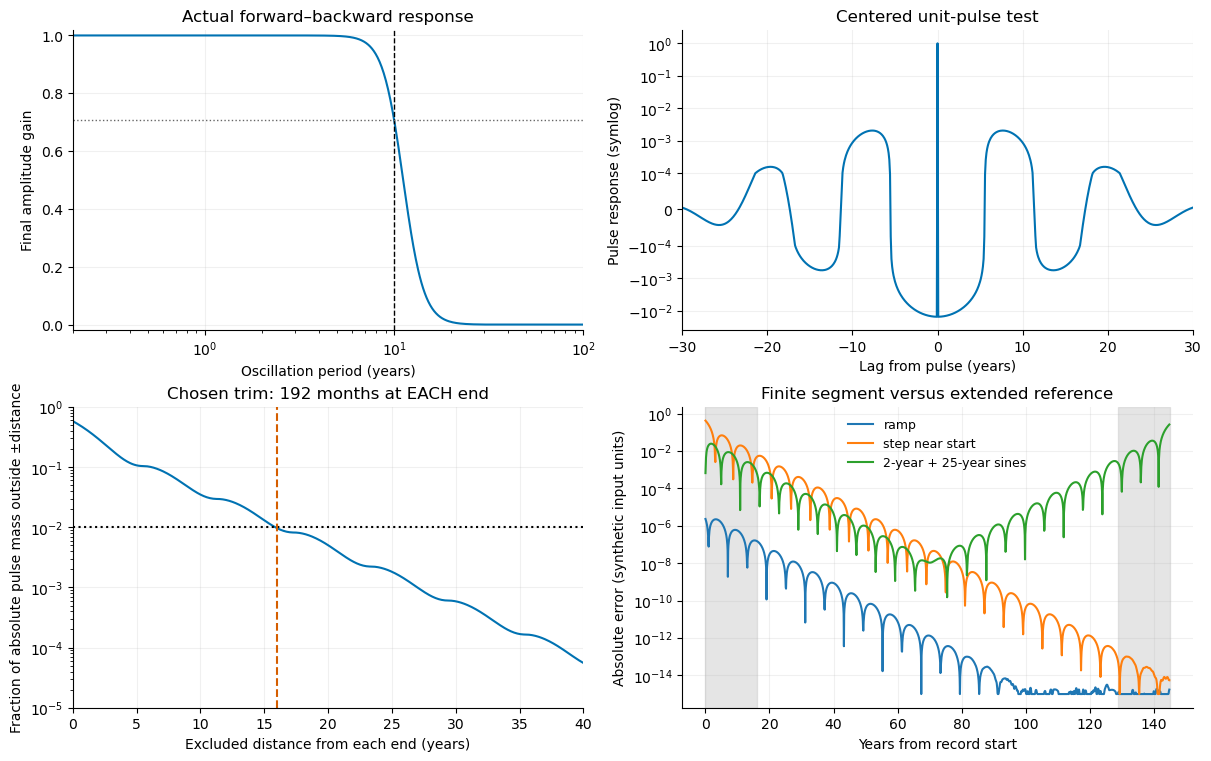

In [7]:
# %% 6. Inspect filter QC BEFORE the expensive model loop
import matplotlib.pyplot as plt
fig_hp_filter, axes_hp_filter = plot_hp_filter(hp_filter)
plt.show()
# The figure is saved in cell 8, after the run directory passes overwrite checks.




In [8]:
# %% 7. Per-member calculation/checkpoints; ensemble means of the diagnostics
def hp_process_field(raw, months, support, filter_info, check_padding):
    """Climatology only -> filter complete record -> common trim -> recenter."""
    raw = np.asarray(raw, dtype=float)
    if raw.shape != (len(months),) + support.shape or not np.isfinite(raw[:, support]).all():
        raise ValueError("Raw input must contain every month, finite on the fixed weighted domain. No automatic interpolation.")
    start_month = int(months[0].astype(int) % 12 + 1)
    anomalies = remove_monthly_climatology_fast(np.where(support[None], raw, 0.), start_month)
    d = filter_info
    filtered = signal.sosfiltfilt(d["sos"], anomalies, axis=0, padtype=d["padtype"], padlen=d["padlen_months"])
    keep = slice(d["trim_months"], len(months)-d["trim_months"])
    result = filtered[keep].copy()
    del filtered
    result -= result.mean(axis=0)
    result[:, ~support] = 0.
    if not np.isfinite(result[:, support]).all():
        raise ValueError("Nonfinite output from high-pass filtering.")
    padding_qc = {"compared": bool(check_padding)}
    if check_padding:
        alternative = "even" if d["padtype"] != "even" else "odd"
        alternate = signal.sosfiltfilt(d["sos"], anomalies, axis=0, padtype=alternative, padlen=d["padlen_months"])[keep].copy()
        alternate -= alternate.mean(axis=0)
        difference = np.sqrt(np.mean((result[:, support] - alternate[:, support])**2, axis=0))
        sd = np.std(result[:, support], axis=0, ddof=1)
        relative = np.divide(difference, sd, out=np.full_like(sd, np.nan), where=sd > 0)
        finite = relative[np.isfinite(relative)]
        padding_qc.update({"alternative": alternative, "relative_rms_p50_p95_max": np.percentile(finite, [50, 95, 100]) if finite.size else np.full(3, np.nan),
                           "absolute_rms_max": float(difference.max())})
    return result, padding_qc


def hp_diagnostics(Ti, Ri, weights, mask):
    """Monthly moments on one common retained sample; no window regression."""
    # Recenter here as well, so the extra-trim sensitivity uses its own means/SDs.
    Ti, Ri = Ti - Ti.mean(axis=0), Ri - Ri.mean(axis=0)
    n, support = len(Ti), weights > 0
    sigma_Ti, sigma_Ri = np.std(Ti, axis=0, ddof=1), np.std(Ri, axis=0, ddof=1)
    variable_T = support & (sigma_Ti > 0) & (np.ptp(Ti, axis=0) > 0)
    if not variable_T[mask].all():
        raise ValueError("A regional T cell has zero filtered variance; its Zi is undefined.")
    p = np.where(mask, weights, 0.)
    p /= p.sum()
    # Divide only region cells to construct A, avoiding a full extra Zi array.
    A = np.sum(Ti[:, mask]/sigma_Ti[mask]*p[mask], axis=1)
    Tg, Rg = [np.einsum("tij,ij->t", field, weights) for field in [Ti, Ri]]
    sigma_A = float(np.std(A, ddof=1)) if np.ptp(A) > 0 else 0.
    D = np.einsum("t,tij->ij", A, Ri)/(n - 1)
    covariance_Ti_R = np.einsum("tij,t->ij", Ti, Rg)/(n - 1)
    cov_Zi_R = np.divide(covariance_Ti_R, sigma_Ti, out=np.full_like(sigma_Ti, np.nan), where=variable_T)
    slope = np.divide(D, sigma_A**2, out=np.full_like(D, np.nan), where=sigma_A > 0)
    correlation = np.divide(D, sigma_A*sigma_Ri, out=np.full_like(D, np.nan), where=(sigma_A > 0) & (sigma_Ri > 0))
    I = float(np.dot(A, Rg)/(n - 1))
    values = {"D": D, "reg_Ri_on_A": slope, "corr_A_Ri": np.clip(correlation, -1., 1.),
              "cov_Zi_R": cov_Zi_R, "sigma_Ti": sigma_Ti, "sigma_Ri": sigma_Ri}
    values = {key: np.where(support, value, np.nan) for key, value in values.items()}
    values.update({"I": I, "sigma_A": sigma_A, "sigma_Tg": float(np.std(Tg, ddof=1)),
                   "sigma_Rg": float(np.std(Rg, ddof=1)), "A": A, "Tg": Tg, "Rg": Rg})
    checks = {"global_D_equals_I": hp_assert_close(np.sum(weights[support]*D[support]), I, "global sum D=I"),
              "regional_cov_equals_I": hp_assert_close(np.sum(p[mask]*cov_Zi_R[mask]), I, "regional cov_Zi_R=I")}
    if sigma_A > 0:
        checks["regression_scaling"] = hp_assert_close((slope*sigma_A**2)[support], D[support], "regression times Var(A)=D")
    return values, checks


# Protect different scientific runs. Changed settings must use a new directory;
# resumption is per complete member, never per partly processed array/window.
if hp_run_dir.exists() and not hp_resume:
    raise FileExistsError(f"Set hp_resume=True only for this unchanged run, or choose a new directory: {hp_run_dir}")
hp_run_dir.mkdir(parents=True, exist_ok=hp_resume)
import inspect
try:
    hp_preprocess_source = inspect.getsource(remove_monthly_climatology_fast)
except (OSError, TypeError):
    hp_preprocess_source = "Source unavailable; use the unchanged supplied climatology-only function."
hp_settings = {"schema": "SEP_fullperiod_HP_v1", "input_months": hp_months, "retained_months": hp_retained_months,
               "lat": hp_lat, "lon": hp_lon, "weights": hp_weights, "region_mask": hp_mask,
               "sos": hp_filter["sos"], "padtype": hp_filter["padtype"], "padlen": hp_filter["padlen_months"],
               "cutoff_convention": hp_cutoff_convention, "tail_tolerance": hp_tail_tolerance, "ddof": hp_ddof,
               "padding_check": hp_padding_check, "extra_trim_months": hp_extra_trim_months,
               "quantity_info": hp_quantity_info, "preprocessing_source": hp_preprocess_source}
hp_run_signature = hp_signature(hp_settings)
hp_member_values, hp_model_mean_values, hp_model_n_valid = [{e: {q: {} for q in hp_quantity_info} for e in hp_experiments} for _ in range(3)]
hp_member_labels, hp_raw_ids, hp_member_checks, hp_member_files = [{e: {} for e in hp_experiments} for _ in range(4)]
hp_calculated = False
for (physical, model), aliases in hp_jobs.items():
    labels = np.asarray(hp_meta["member_labels"][aliases[0]][model])
    if labels.ndim != 1 or not len(labels) or len(set(labels.tolist())) != len(labels):
        raise ValueError(f"{model}: invalid member labels.")
    for alias in aliases:
        if not np.array_equal(labels, hp_meta["member_labels"][alias][model]):
            raise ValueError(f"{model}: historical/matched member order differs.")
    print(f"{physical} / {model}: {len(labels)} members", flush=True)
    folder, tag = ("AMIP", "amip-hist") if physical == "amip_hist" else ("HIST", "historical")
    paths = {}
    for variable in ["tas", "N"]:
        matches = sorted((hp_raw_dir / folder / model).glob(f"{variable}_Amon_{model}_*{tag}*combined*187001-201412_g025.nc"))
        if len(matches) != 1:
            raise ValueError(f"{model}/{variable}: expected one combined file; found {matches}")
        paths[variable] = matches[0]
    sources = {v: {"path": str(p), "size_bytes": p.stat().st_size, "mtime_ns": p.stat().st_mtime_ns} for v, p in paths.items()}
    collected, checks, files = {q: [] for q in hp_quantity_info}, [], []

    # Each raw file stays open for this model only. Read/filter one member and
    # one field at a time; only compact maps and global/regional series persist.
    with xr.open_dataset(paths["tas"]) as ds_T, xr.open_dataset(paths["N"]) as ds_R:
        fields = {"tas": hp_prepare_raw(ds_T["tas"], hp_months, hp_lat, hp_lon),
                  "N": hp_prepare_raw(ds_R["N"], hp_months, hp_lat, hp_lon)}
        ids = None if hp_confirmed_member_ids is None else np.asarray(hp_confirmed_member_ids[physical][model]).astype(str)
        if ids is None and hp_meta.get("member_label_kind") == "user-confirmed member IDs":
            ids = labels.astype(str)
        if ids is not None:
            if ids.shape != labels.shape or len(set(ids.tolist())) != len(labels):
                raise ValueError(f"{model}: invalid confirmed member IDs.")
            fields = {v: field.sel(member=ids) for v, field in fields.items()}
        if any(field.sizes["member"] != len(labels) for field in fields.values()) or not np.array_equal(fields["tas"].member, fields["N"].member):
            raise ValueError(f"{model}: raw T/R member counts/order differ; supply confirmed IDs.")
        sources["alignment"] = "confirmed IDs" if ids is not None else "assumed original file positions; raw T/N labels agree"
        units_allowed = {"tas": {"K", "kelvin", "Kelvin"}, "N": {"W m-2", "W m^-2", "W m**-2", "W/m2", "W/m^2", "W m−2"}}
        for variable, field in fields.items():
            unit = field.attrs.get("units")
            if unit is not None and unit not in units_allowed[variable]:
                raise ValueError(f"{model}/{variable}: convert units {unit!r} explicitly.")
            sources[variable]["units"] = unit or "Missing label: assuming tas=K and N=W m-2"
        raw_ids = fields["tas"].member.values.copy()

        for member, label in enumerate(labels):
            path = Path("members") / physical / model / f"member_{member:03d}.npy"
            saved = hp_load_member(hp_run_dir/path, hp_run_signature, label, raw_ids[member], sources,
                                   hp_shapes, hp_weights, hp_mask) if hp_resume else None
            if saved is not None:
                print(f"  member {member + 1}: reused checked checkpoint", flush=True)
            else:
                print(f"  member {member + 1}: climatology -> filter -> trim -> moments", flush=True)
                Ti, qc_T = hp_process_field(fields["tas"].isel(member=member).values, hp_months, hp_support, hp_filter, hp_padding_check)
                Ri, qc_R = hp_process_field(fields["N"].isel(member=member).values, hp_months, hp_support, hp_filter, hp_padding_check)
                values, closure = hp_diagnostics(Ti, Ri, hp_weights, hp_mask)
                member_qc = {"closure_max_abs_error": closure, "padding_Ti": qc_T, "padding_Ri": qc_R}
                if hp_extra_trim_months > 0:
                    extra = hp_extra_trim_months
                    alternate, _ = hp_diagnostics(Ti[extra:-extra], Ri[extra:-extra], hp_weights, hp_mask)
                    difference = alternate["D"][hp_support] - values["D"][hp_support]
                    rms = np.sqrt(np.sum(hp_weights[hp_support]*values["D"][hp_support]**2))
                    rmse = np.sqrt(np.sum(hp_weights[hp_support]*difference**2))
                    member_qc["extra_trim"] = {"months_each_end": extra, "D_area_rmse": float(rmse),
                                               "D_rmse_over_original_rms": float(rmse/rms) if rms > 0 else np.nan,
                                               "I_extra_trim": alternate["I"]}
                    del alternate
                del Ti, Ri
                saved = {"values": values, "checks": member_qc, "member_label": label,
                         "raw_id": str(raw_ids[member]), "sources": sources, "signature": hp_run_signature}
                hp_save(hp_run_dir/path, saved)
                if hp_padding_check:
                    print(f"    Padding sensitivity p95 (RMS difference/SD): T={qc_T['relative_rms_p50_p95_max'][1]:.3g}, R={qc_R['relative_rms_p50_p95_max'][1]:.3g}", flush=True)
            for key in hp_quantity_info:
                collected[key].append(saved["values"][key])
            checks.append(saved["checks"])
            files.append(str(path))
            del saved

    # Ordinary means of MEMBER DIAGNOSTICS. We never compute D from ensemble-
    # mean monthly T/R; that would answer a different question. Matched coupled
    # groups reuse these same arrays/files but have their own subsequent MMM.
    stacked = {q: np.stack(values, axis=0) for q, values in collected.items()}
    means_and_counts = {q: hp_mean(values) for q, values in stacked.items()}
    for alias in aliases:
        for key in hp_quantity_info:
            hp_member_values[alias][key][model] = stacked[key]
            hp_model_mean_values[alias][key][model], hp_model_n_valid[alias][key][model] = means_and_counts[key]
        hp_member_labels[alias][model], hp_raw_ids[alias][model] = labels.copy(), raw_ids.copy()
        hp_member_checks[alias][model], hp_member_files[alias][model] = checks, files
    del collected, stacked, means_and_counts
hp_calculated = True




historical / ACCESS-CM2: 3 members
  member 1: climatology -> filter -> trim -> moments
    Padding sensitivity p95 (RMS difference/SD): T=0.0053, R=0.00506
  member 2: climatology -> filter -> trim -> moments
    Padding sensitivity p95 (RMS difference/SD): T=0.00522, R=0.00512
  member 3: climatology -> filter -> trim -> moments
    Padding sensitivity p95 (RMS difference/SD): T=0.00532, R=0.00515
historical / ACCESS-ESM1-5: 30 members
  member 1: climatology -> filter -> trim -> moments
    Padding sensitivity p95 (RMS difference/SD): T=0.00515, R=0.00523
  member 2: climatology -> filter -> trim -> moments
    Padding sensitivity p95 (RMS difference/SD): T=0.00551, R=0.00539
  member 3: climatology -> filter -> trim -> moments
    Padding sensitivity p95 (RMS difference/SD): T=0.00528, R=0.00481
  member 4: climatology -> filter -> trim -> moments
    Padding sensitivity p95 (RMS difference/SD): T=0.00554, R=0.00519
  member 5: climatology -> filter -> trim -> moments
    Padding s

In [9]:
# %% 8. Equal-model MMM, final save, and the filter-QC figure
if not hp_calculated:
    raise RuntimeError("Finish the member calculation before aggregation/save.")
hp_MMM_values, hp_MMM_n_valid = [{e: {} for e in hp_experiments} for _ in range(2)]
for experiment in hp_experiments:
    for key in hp_quantity_info:
        maps_or_series = np.stack([hp_model_mean_values[experiment][key][m] for m in hp_model_names[experiment]])
        hp_MMM_values[experiment][key], hp_MMM_n_valid[experiment][key] = hp_mean(maps_or_series)
    # Linearity preserves this budget through both averaging levels.
    hp_assert_close(np.sum(hp_weights[hp_support]*hp_MMM_values[experiment]["D"][hp_support]), hp_MMM_values[experiment]["I"], f"{experiment}: MMM budget")

hp_archive = {"member_values": hp_member_values, "model_mean_values": hp_model_mean_values, "MMM_values": hp_MMM_values,
              "model_n_valid": hp_model_n_valid, "MMM_n_valid": hp_MMM_n_valid, "model_names": hp_model_names,
              "member_labels": hp_member_labels, "raw_ids": hp_raw_ids, "member_checks": hp_member_checks,
              "member_files": hp_member_files, "quantity_info": hp_quantity_info, "filter": hp_filter,
              "coordinates": {"lat": hp_lat, "lon": hp_lon, "input_time": hp_months, "time": hp_retained_months},
              "weights": hp_weights, "region_mask": hp_mask, "signature": hp_run_signature,
              "metadata": {"created_utc": datetime.now(timezone.utc).isoformat(), "region": hp_region,
              "regional_source": str(hp_regional_path), "settings": hp_settings,
              "preprocessing": "Calendar-month climatology only; zero-phase high-pass; common edge trim; recenter; retained-period standardization",
              "aggregation": "Arithmetic member diagnostics -> model mean -> equal-model MMM. No Fisher transform, no pooled statistics.",
              "scope": "High-pass variability; no forced-response subtraction, LFCA, observations or causal attribution"}}
hp_save(hp_run_dir/"highpass_attribution.npy", hp_archive, replace=hp_resume)
if hp_save_figures:
    (hp_run_dir/"figures").mkdir(exist_ok=True)
    fig_hp_filter.savefig(hp_run_dir/"figures/filter_QC.png", dpi=200, bbox_inches="tight")
print(f"Saved {hp_run_dir/'highpass_attribution.npy'}")




Saved /scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/fullperiod_highpass/SEP_10yr_run01/highpass_attribution.npy


In [10]:
# %% 9. Load block: enough for plotting in a new session after running settings
hp_archive = np.load(hp_run_dir/"highpass_attribution.npy", allow_pickle=True).item()  # Trusted pickle files only.
hp_member_values = hp_archive["member_values"]
hp_model_mean_values = hp_archive["model_mean_values"]
hp_MMM_values = hp_archive["MMM_values"]
hp_model_names, hp_member_labels = hp_archive["model_names"], hp_archive["member_labels"]
hp_filter = hp_archive["filter"]

# Examples, using the familiar experiment -> quantity -> model organization:
# hp_member_values['amip_hist']['D']['TaiESM1']       # (member,lat,lon)
# hp_model_mean_values['amip_hist']['D']['TaiESM1']   # (lat,lon), mean MEMBER covariance
# hp_MMM_values['historical_matched']['D']           # (lat,lon), equal-model MMM
# hp_member_values['amip_hist']['A']['TaiESM1']       # (member,retained_month)
# hp_archive['member_checks']['amip_hist']['TaiESM1'][0]
# hp_archive['coordinates']['time'][[0,-1]]          # Actual retained dates, not 1870–2014 endpoints.




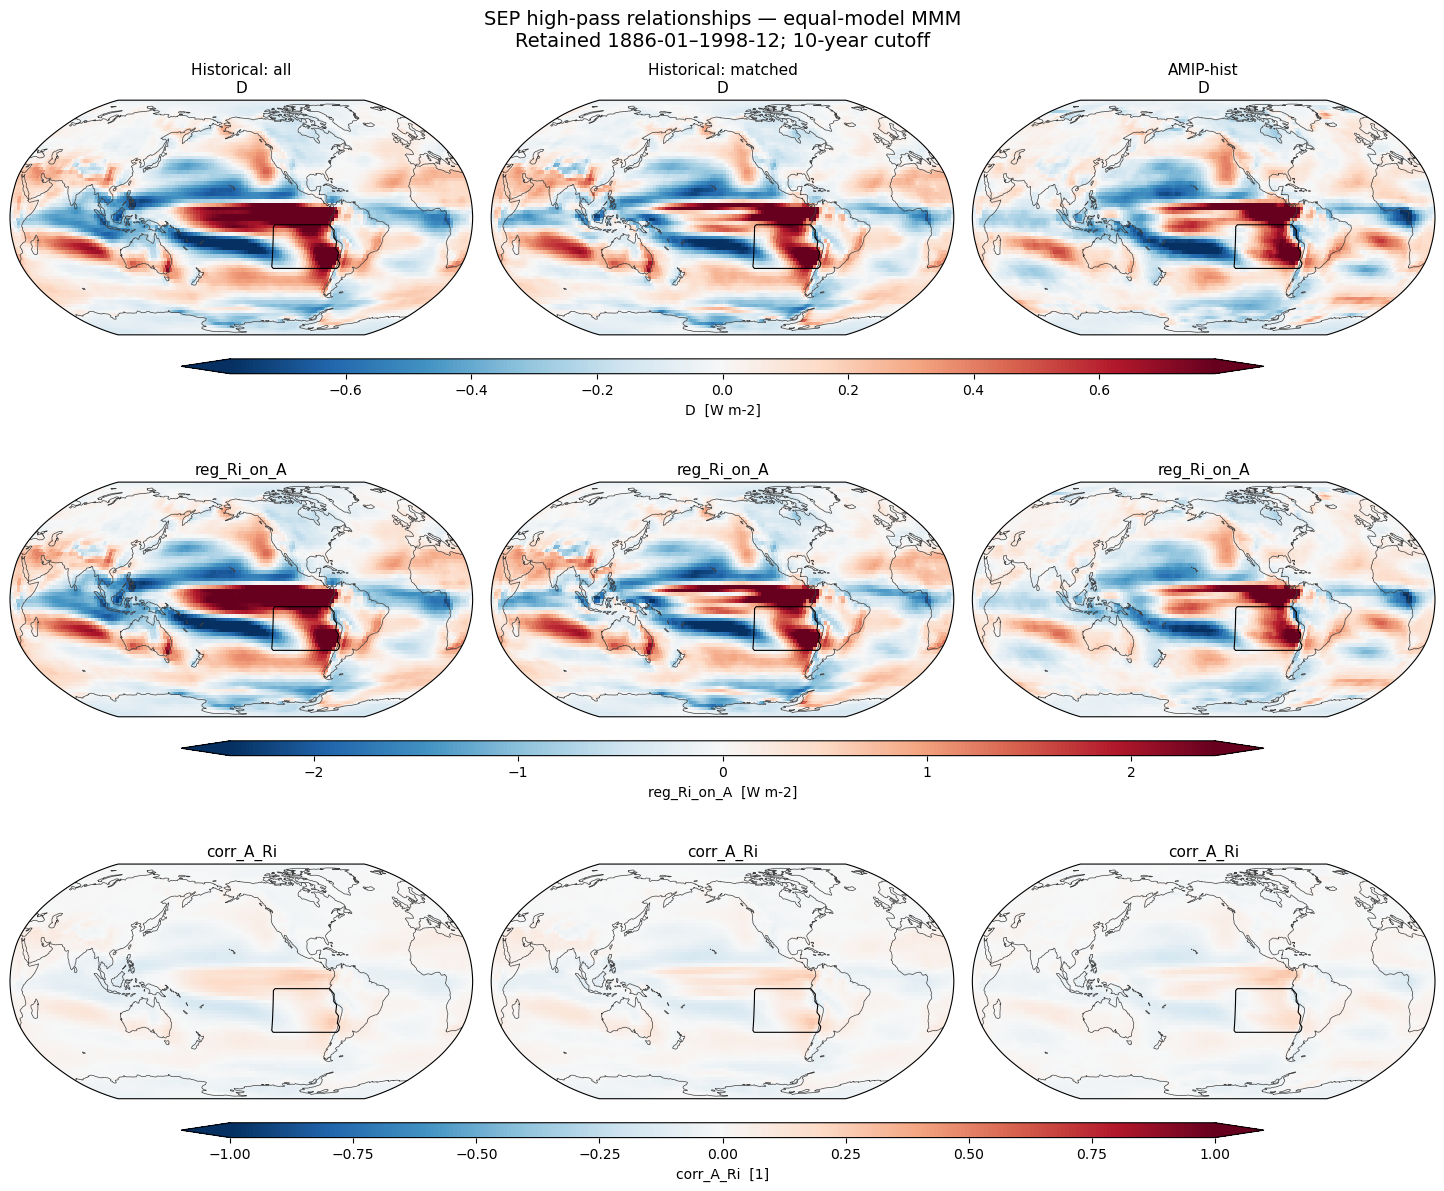

In [11]:
# %% 10. Three-experiment MMM maps: covariance, actual regression, correlation
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

def hp_draw_map(ax, field, lat, lon, mask, limit, *, cmap="RdBu_r", coastlines=True):
    data, plot_lon = add_cyclic_point(field, coord=lon, axis=-1)
    im = ax.pcolormesh(plot_lon, lat, data, shading="auto", cmap=cmap, vmin=-limit, vmax=limit, transform=ccrs.PlateCarree())
    boundary, _ = add_cyclic_point(mask.astype(float), coord=lon, axis=-1)
    ax.contour(plot_lon, lat, boundary, levels=[.5], colors="black", linewidths=.8, transform=ccrs.PlateCarree())
    if coastlines:
        ax.coastlines(linewidth=.5, color=".25")
    ax.set_global()
    return im


def plot_hp_MMM(archive, quantities=("D", "reg_Ri_on_A", "corr_A_Ri"), *, experiments=None,
                vlims=None, percentile=98, cmap="RdBu_r", central_longitude=210, coastlines=True, savepath=None):
    experiments = list(archive["model_names"]) if experiments is None else list(experiments)
    lat, lon, time = [archive["coordinates"][k] for k in ["lat", "lon", "time"]]
    rows, cols = len(quantities), len(experiments)
    fig = plt.figure(figsize=(5*cols, 3.9*rows + 1))
    grid = fig.add_gridspec(3*rows, cols, height_ratios=[1, .06, .27]*rows,
                          left=.025, right=.975, top=1-1.1/fig.get_size_inches()[1], bottom=.025, hspace=.16, wspace=.04)
    axes = np.empty((rows, cols), dtype=object)
    names = {"historical": "Historical: all", "historical_matched": "Historical: matched", "amip_hist": "AMIP-hist"}
    for row, key in enumerate(quantities):
        maps = np.stack([archive["MMM_values"][e][key] for e in experiments])
        if maps.shape[1:] != (len(lat), len(lon)):
            raise ValueError(f"{key}: choose a map quantity.")
        finite = np.abs(maps[np.isfinite(maps)])
        limit = 1. if key.startswith("corr_") else max(float(np.percentile(finite, percentile)), 1e-12) if finite.size else 1.
        limit = limit if vlims is None else float(vlims[row])
        if not np.isfinite(limit) or limit <= 0:
            raise ValueError("Color limits must be positive and finite.")
        for col, experiment in enumerate(experiments):
            ax = fig.add_subplot(grid[3*row, col], projection=ccrs.Robinson(central_longitude=central_longitude))
            axes[row, col] = ax
            im = hp_draw_map(ax, maps[col], lat, lon, archive["region_mask"], limit, cmap=cmap, coastlines=coastlines)
            ax.set_title((names.get(experiment, experiment) + "\n" if row == 0 else "") + key, fontsize=11)
        cax = fig.add_subplot(grid[3*row + 1, :])
        pos = cax.get_position()
        cax.set_position([pos.x0 + .12*pos.width, pos.y0, .76*pos.width, pos.height])
        bar = fig.colorbar(im, cax=cax, orientation="horizontal", extend="both")
        bar.set_label(f"{key}  [{archive['quantity_info'][key]['units']}]", fontsize=10)
    fig.suptitle(f"{archive['metadata']['region']} high-pass relationships — equal-model MMM\nRetained {time[0]}–{time[-1]}; {archive['filter']['cutoff_years']:g}-year cutoff", fontsize=14, y=.98)
    if savepath is not None:
        Path(savepath).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=220, bbox_inches="tight")
    return fig, axes


fig_hp_MMM, axes_hp_MMM = plot_hp_MMM(hp_archive, savepath=hp_run_dir/"figures/MMM_D_reg_corr.png" if hp_save_figures else None)
plt.show()
# For just D, use quantities=['D']; vlims=[0.4] would set a manual shared limit.




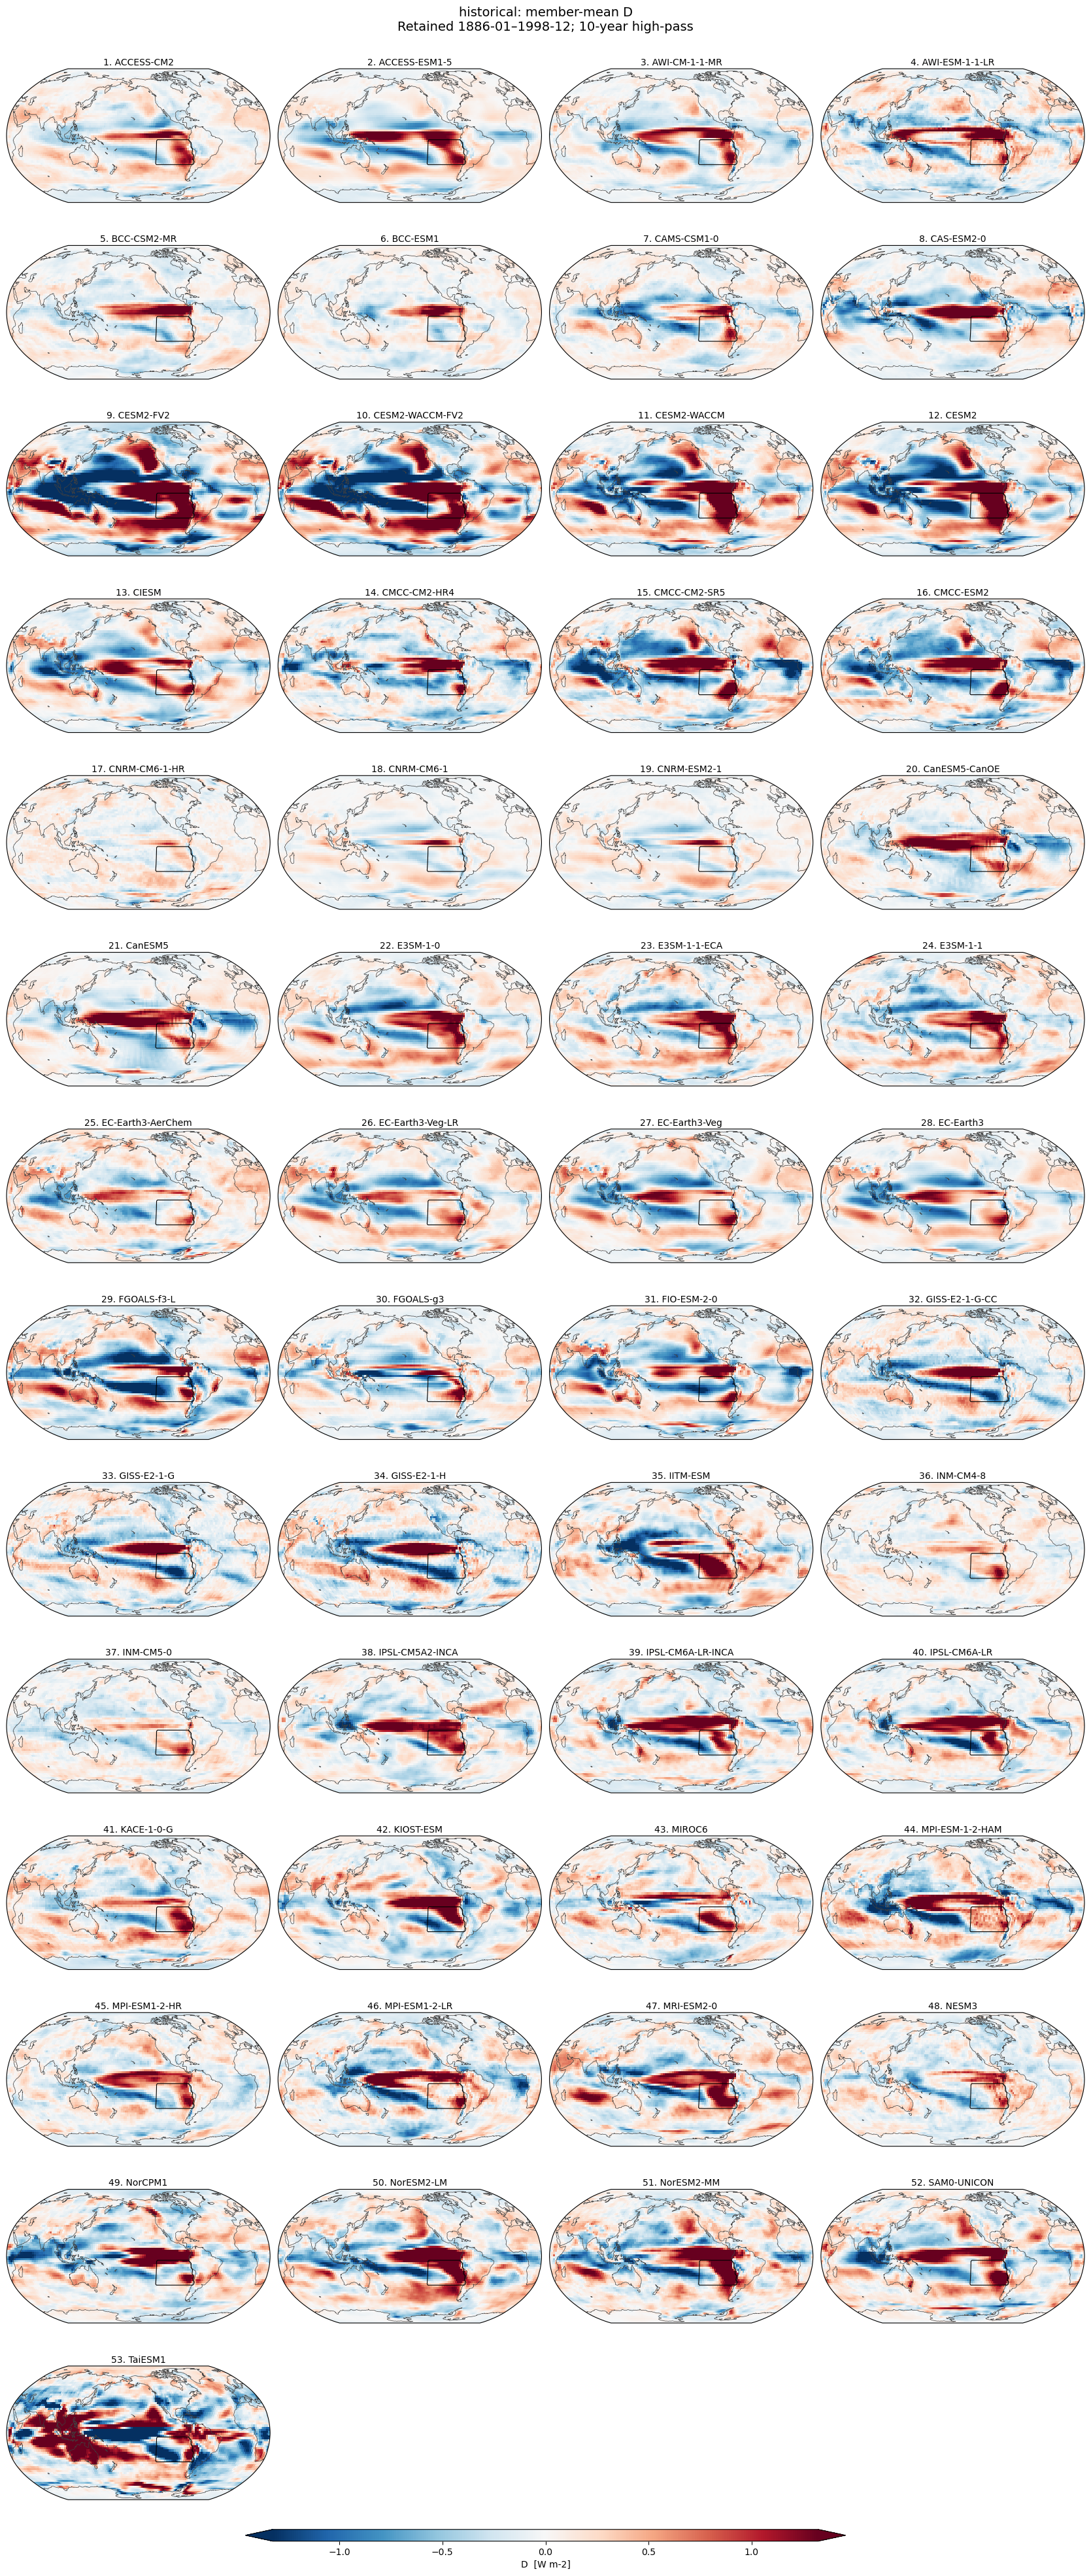

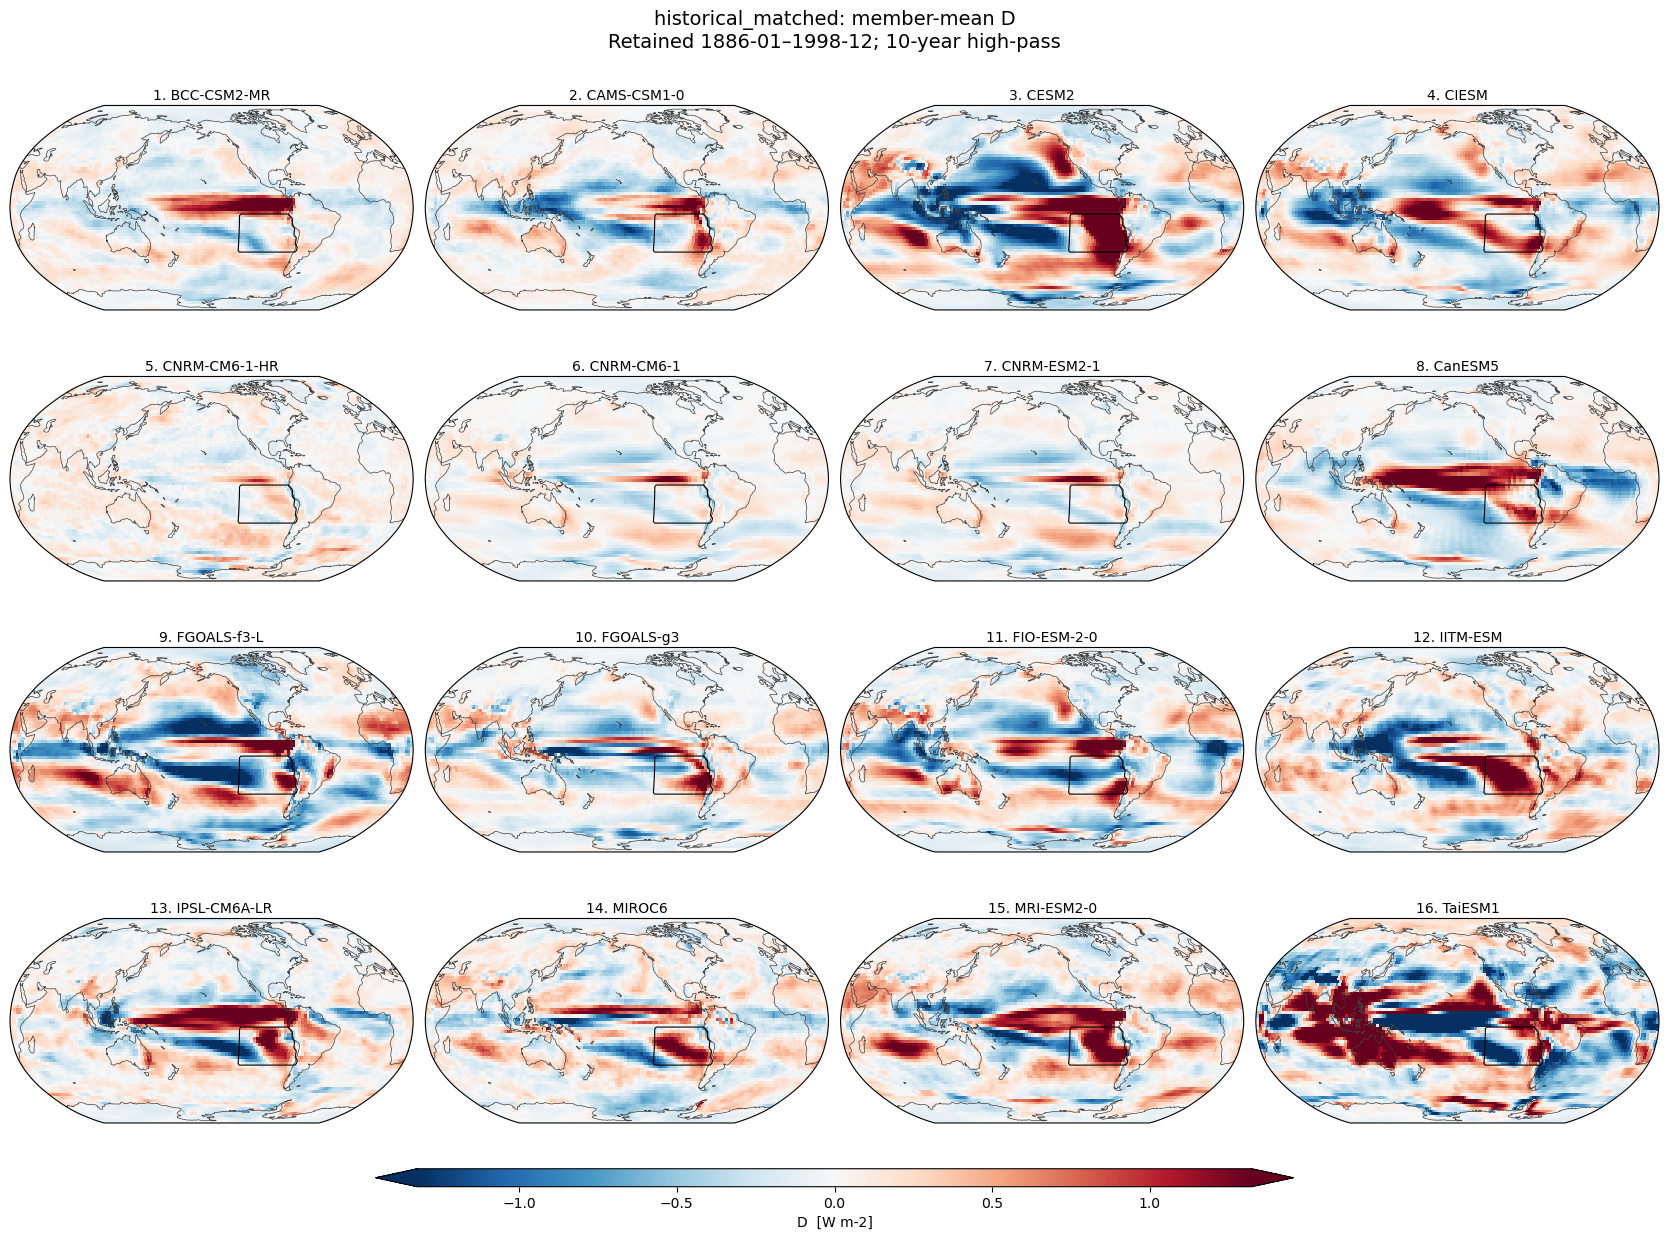

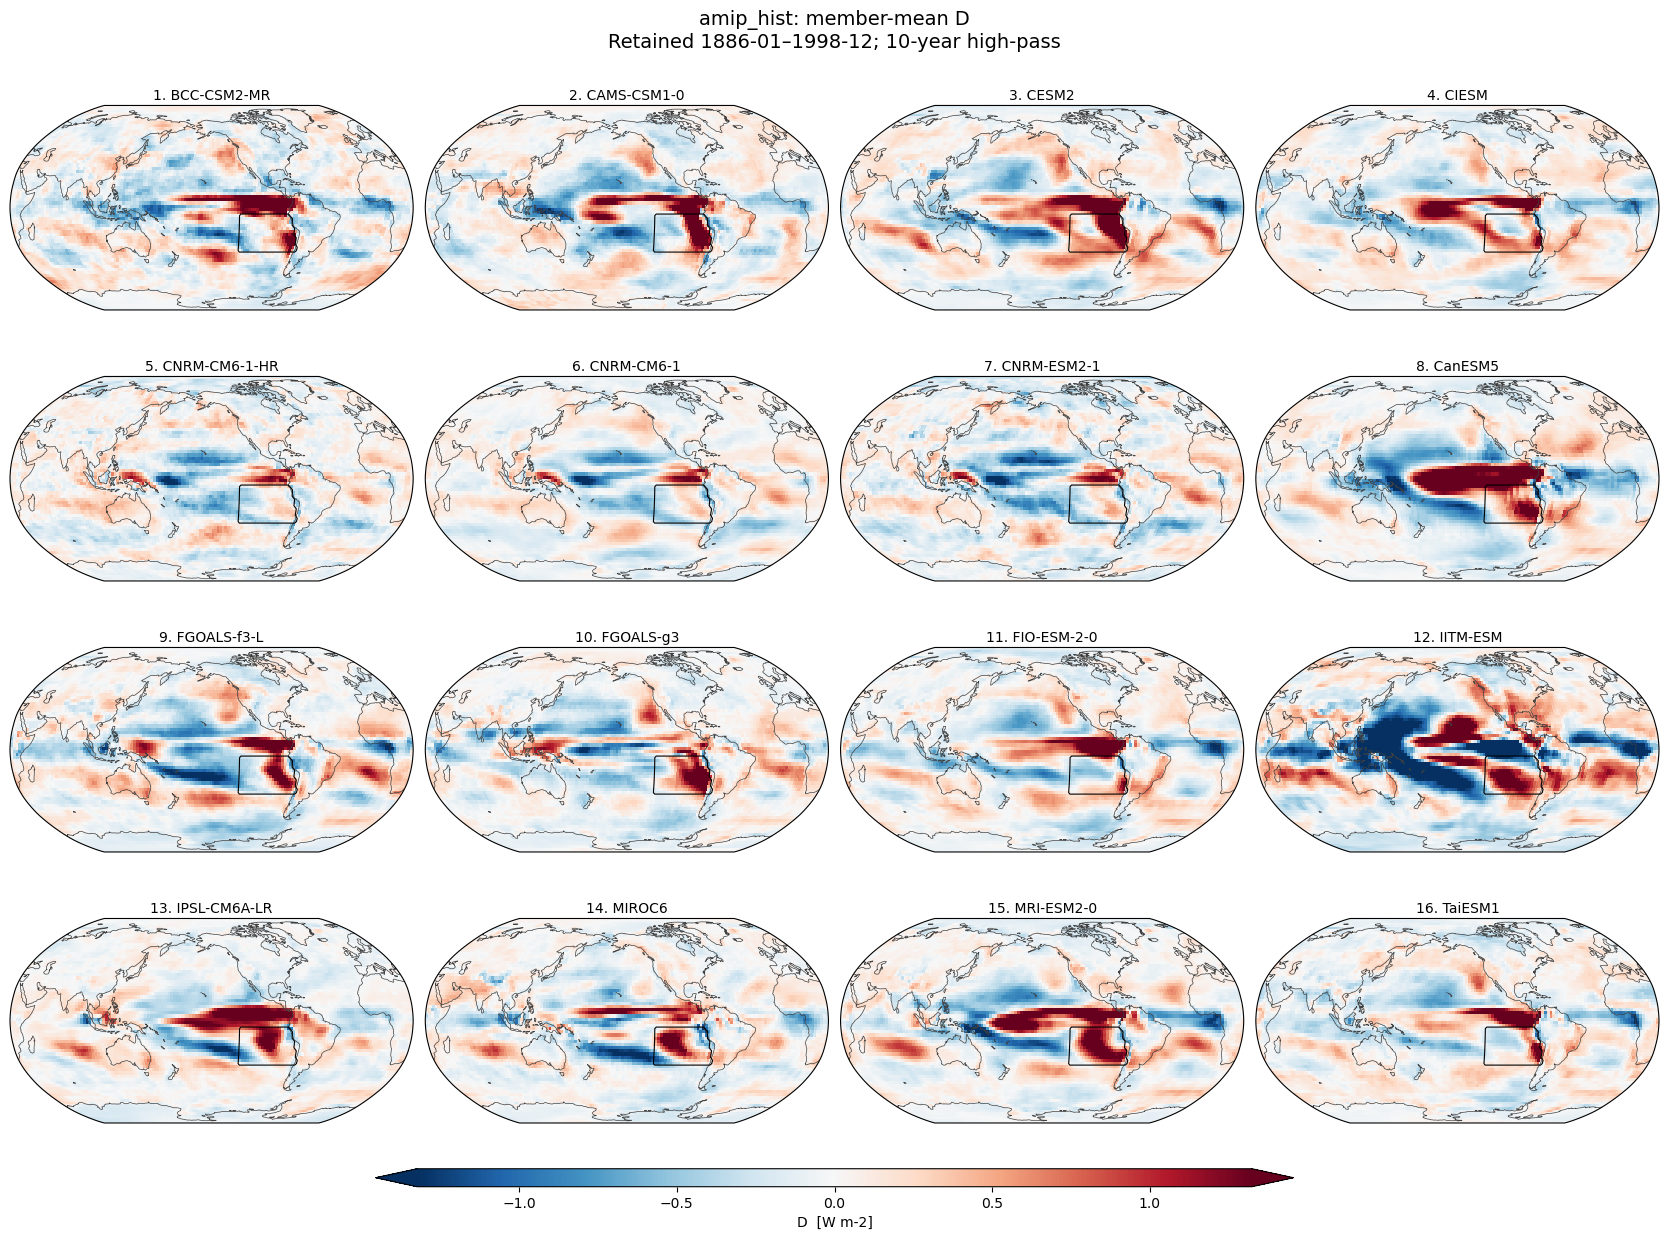

In [12]:
# %% 11. Member-mean D for every model, keeping four columns and all three groups
def plot_hp_model_means(archive, experiment, quantity="D", *, vlim=None, percentile=98,
                        central_longitude=210, cmap="RdBu_r", coastlines=True, savepath=None):
    names = archive["model_names"][experiment]
    lat, lon, time = [archive["coordinates"][k] for k in ["lat", "lon", "time"]]
    maps = np.stack([archive["model_mean_values"][experiment][quantity][m] for m in names])
    if maps.shape[1:] != (len(lat), len(lon)):
        raise ValueError("Choose a map quantity.")
    finite = np.abs(maps[np.isfinite(maps)])
    if vlim is None:
        vlim = 1. if quantity.startswith("corr_") else max(float(np.percentile(finite, percentile)), 1e-12) if finite.size else 1.
    if not np.isfinite(vlim) or vlim <= 0:
        raise ValueError("vlim must be positive and finite.")
    nrows = int(np.ceil(len(names)/4))
    fig, axes = plt.subplots(nrows, 4, figsize=(17, 2.7*nrows + 1.6), squeeze=False,
                             subplot_kw={"projection": ccrs.Robinson(central_longitude=central_longitude)})
    for i, ax in enumerate(axes.ravel()):
        if i >= len(names):
            ax.set_visible(False)
            continue
        im = hp_draw_map(ax, maps[i], lat, lon, archive["region_mask"], vlim, cmap=cmap, coastlines=coastlines)
        ax.set_title(f"{i + 1}. {names[i]}", fontsize=10, pad=4)
    height = fig.get_size_inches()[1]
    fig.subplots_adjust(left=.015, right=.985, top=1-.85/height, bottom=1./height, wspace=.03, hspace=.12)
    cax = fig.add_axes([.23, .55/height, .54, .18/height])
    bar = fig.colorbar(im, cax=cax, orientation="horizontal", extend="both")
    bar.set_label(f"{quantity}  [{archive['quantity_info'][quantity]['units']}]", fontsize=10)
    fig.suptitle(f"{experiment}: member-mean {quantity}\nRetained {time[0]}–{time[-1]}; {archive['filter']['cutoff_years']:g}-year high-pass", fontsize=14, y=1-.08/height)
    if savepath is not None:
        Path(savepath).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=220, bbox_inches="tight")
    return fig, axes


# One color scale across ALL model-mean D maps makes these three figures comparable.
hp_scale_groups = [e for e in ["historical", "amip_hist"] if e in hp_model_names]
if not hp_scale_groups:
    hp_scale_groups = ["historical_matched"]
hp_all_D = np.stack([hp_model_mean_values[e]["D"][m] for e in hp_scale_groups for m in hp_model_names[e]])
hp_finite_D = np.abs(hp_all_D[np.isfinite(hp_all_D)])
hp_model_vlim = max(float(np.percentile(hp_finite_D, 98)), 1e-12) if hp_finite_D.size else 1.
hp_model_figures = {}
for experiment in hp_model_names:
    path = hp_run_dir/f"figures/{experiment}_model_mean_D.png" if hp_save_figures else None
    hp_model_figures[experiment] = plot_hp_model_means(hp_archive, experiment, vlim=hp_model_vlim, savepath=path)
    plt.show()
